In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
os.environ["PYTHONUTF8"] = "1"
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd

from src.ssm_models import LocalLinearTrendSeasonalWithMultiFixedExog
from src.data_loader import load_connected_parcel_data
from src.features import prepare_event_data
from src.visualization import ThesisVisualizer

In [ ]:
# 統合版データ
DATA_PATH = "../data/processed/parcel_volume_connected.csv"

# モデル推定用の外生変数定義
# post_stat_change は「需要イベント」ではなく「統計定義変更の補正項」
custom_events = {
    "hike_dummy":       ("2017-10-01", "2019-12-31"),
    "covid_main":       ("2020-03-01", None),
    "covid_wave1":      ("2020-04-01", "2020-05-31"),
    "covid_2021":       ("2021-01-01", "2021-09-30"),
    "post_stat_change": ("2022-08-01", None),
}

# 可視化用のイベント定義
# post_stat_change は統計接続補正なので、背景帯やイベント効果図からは除外
plot_events = {
    "hike_dummy":  ("2017-10-01", "2019-12-31"),
    "covid_main":  ("2020-03-01", None),
    "covid_wave1": ("2020-04-01", "2020-05-31"),
    "covid_2021":  ("2021-01-01", "2021-09-30"),
}

# post_stat_change は大手3社系列への切り替えによる水準差を補正する項
# 重複期間で大手3社が旧系列の約95.5%なら log(0.955) ≈ -0.046 程度が自然?
coeff_hints = {
    "hike_dummy": 0.0,
    "covid_main": 0.0,
    "covid_wave1": 0.0,
    "covid_2021": 0.0,
    "post_stat_change": np.log(0.955),
}

In [3]:
# (1) データの読み込み
df = load_connected_parcel_data(DATA_PATH)

print(df.head())
print(df.tail())
print(df[["number_parcels", "y", "post_stat_change"]].head())
print(df[["number_parcels", "y", "post_stat_change"]].tail())

            year  month  Transport_tonnage  number_parcels  post_stat_change  \
label                                                                          
2002-04-01  2002      4          5933686.0        218721.0                 0   
2002-05-01  2002      5          5474539.0        208283.0                 0   
2002-06-01  2002      6          5430018.0        218633.0                 0   
2002-07-01  2002      7          6345951.0        271764.0                 0   
2002-08-01  2002      8          5354671.0        217650.0                 0   

                    y  
label                  
2002-04-01  12.295552  
2002-05-01  12.246653  
2002-06-01  12.295150  
2002-07-01  12.512689  
2002-08-01  12.290644  
            year  month  Transport_tonnage  number_parcels  post_stat_change  \
label                                                                          
2025-10-01  2025     10           204844.0        405217.0                 1   
2025-11-01  2025     11        

In [4]:
# (2) 外生変数の準備
df, exog_data, exog_names = prepare_event_data(df, custom_events)

print("使用する外生変数:")
print(exog_names)

df[exog_names].sum()

使用する外生変数:
['hike_dummy', 'covid_main', 'covid_wave1', 'covid_2021', 'post_stat_change']


hike_dummy          27
covid_main          72
covid_wave1          2
covid_2021           9
post_stat_change    43
dtype: int64

In [5]:
# (3) パラメータ名の自動生成

# 基本パラメータ
base_params = [
    "obs_error",
    "level_noise",
    "slope_noise",
    "seasonal_noise",
]

# 外生変数パラメータ
exog_params = [f"{name}_effect" for name in exog_names]

all_param_names = base_params + exog_params

print("推定パラメータ:")
for name in all_param_names:
    print(name)

推定パラメータ:
obs_error
level_noise
slope_noise
seasonal_noise
hike_dummy_effect
covid_main_effect
covid_wave1_effect
covid_2021_effect
post_stat_change_effect


In [6]:
# (4) 初期値の自動生成

init_variances = [
    0.01,   # obs_error
    0.01,   # level_noise
    0.001,  # slope_noise
    0.001,  # seasonal_noise
]

init_coeffs = [coeff_hints.get(name, 0.0) for name in exog_names]

start_params = init_variances + init_coeffs

print("start_params:")
for name, value in zip(all_param_names, start_params):
    print(f"{name}: {value}")

start_params:
obs_error: 0.01
level_noise: 0.01
slope_noise: 0.001
seasonal_noise: 0.001
hike_dummy_effect: 0.0
covid_main_effect: 0.0
covid_wave1_effect: 0.0
covid_2021_effect: 0.0
post_stat_change_effect: -0.046043938501406846


In [7]:
# (5) モデルの構築と推定

print(f"モデルを構築します。使用する外生変数: {exog_names}")

model = LocalLinearTrendSeasonalWithMultiFixedExog(
    endog=df["y"],
    exog_list=exog_data,
    param_names=all_param_names,
    seasonal_period=12,
)

result = model.fit(
    start_params=start_params,
    maxiter=1000,
    disp=False,
)

print(result.summary())

モデルを構築します。使用する外生変数: ['hike_dummy', 'covid_main', 'covid_wave1', 'covid_2021', 'post_stat_change']


c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                       Statespace Model Results                                       
Dep. Variable:                                              y   No. Observations:                  287
Model:             LocalLinearTrendSeasonalWithMultiFixedExog   Log Likelihood                 584.081
Date:                                        Tue, 16 Jun 2026   AIC                          -1124.161
Time:                                                16:56:56   BIC                          -1043.653
Sample:                                            04-01-2002   HQIC                         -1091.895
                                                 - 02-01-2026                                         
Covariance Type:                                          opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [9]:
# (6) 推定結果の表

params_df = pd.DataFrame({
    "estimate": result.params,
})

params_df

,estimate
obs_error,2.274731e-04
level_noise,7.667658e-05
slope_noise,1.127960e-11
seasonal_noise,5.529391e-05
hike_dummy_effect,-3.102666e-02
covid_main_effect,3.724710e-02
covid_wave1_effect,4.328194e-02
covid_2021_effect,1.535513e-02
post_stat_change_effect,-4.266373e-02


c:\Users\fugat\Desktop\python_project\Transport_amount_project\src\visualization.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = self.result.params[self.n_base_params + i]


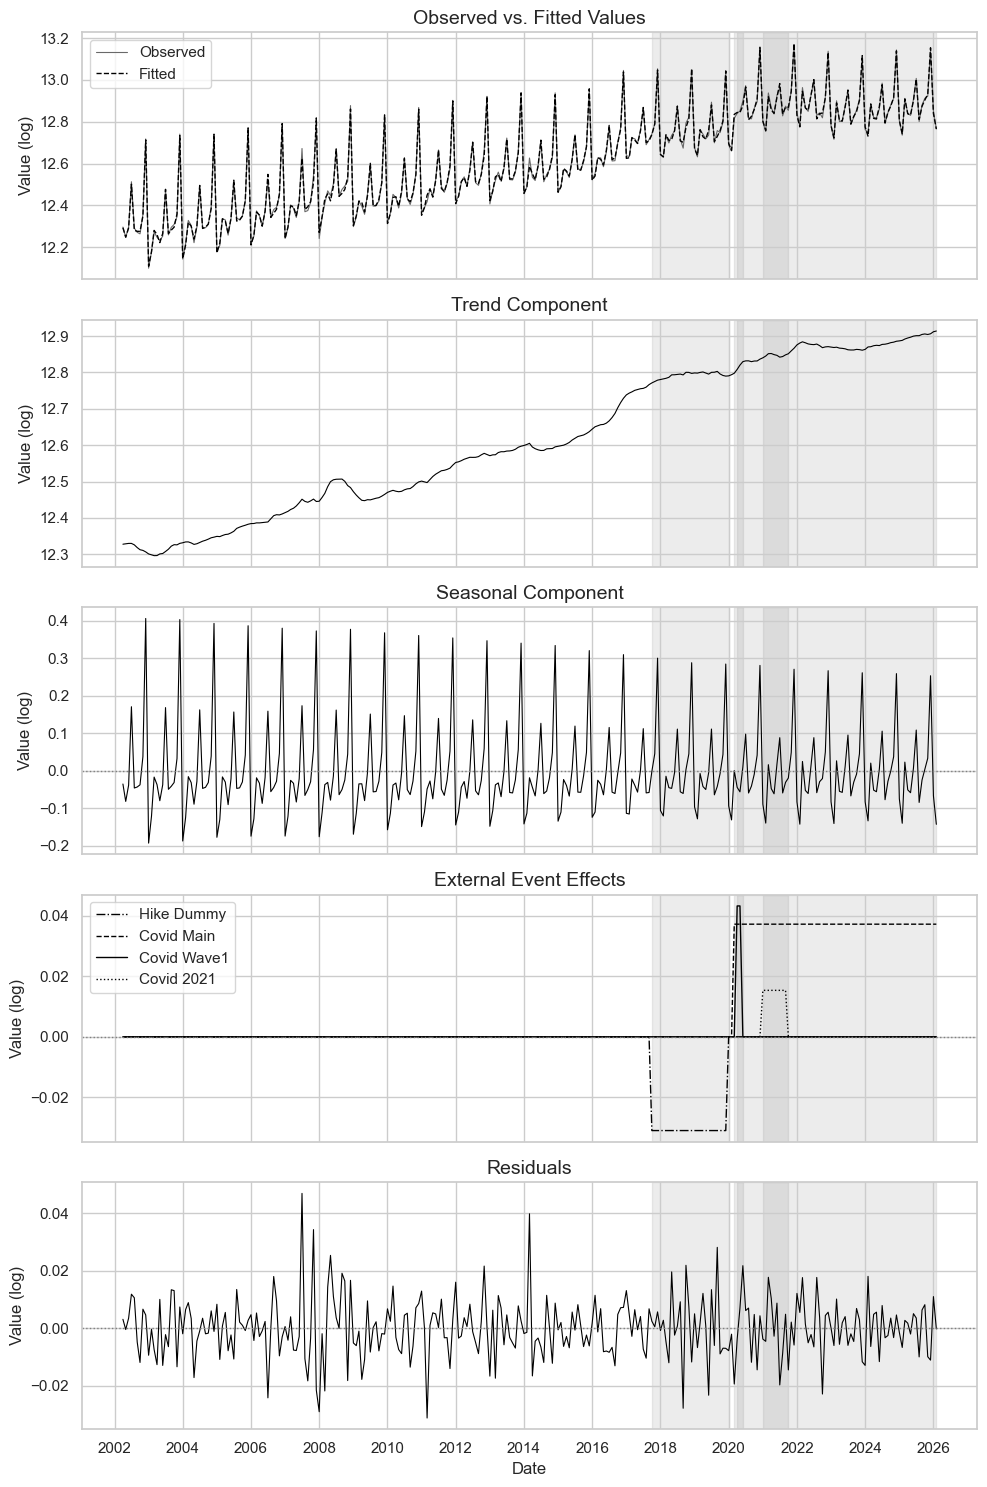

(<Figure size 1000x1500 with 5 Axes>,
 array([<Axes: title={'center': 'Observed vs. Fitted Values'}, ylabel='Value (log)'>,
        <Axes: title={'center': 'Trend Component'}, ylabel='Value (log)'>,
        <Axes: title={'center': 'Seasonal Component'}, ylabel='Value (log)'>,
        <Axes: title={'center': 'External Event Effects'}, ylabel='Value (log)'>,
        <Axes: title={'center': 'Residuals'}, xlabel='Date', ylabel='Value (log)'>],
       dtype=object))

In [10]:
# (8) 可視化
# post_stat_change は推定には含めるが、イベント効果図には表示しない

effects_to_plot = [
    "hike_dummy",
    "covid_main",
    "covid_wave1",
    "covid_2021",
]

viz = ThesisVisualizer(
    result=result,
    df=df,
    exog_names=exog_names,
    event_config=plot_events,
    effects_to_plot=effects_to_plot,
)

viz.plot_reproduction()

In [11]:
# 接続ダミーなしモデルとの比較用

custom_events_no_connection = {
    "hike_dummy":  ("2017-10-01", "2019-12-31"),
    "covid_main":  ("2020-03-01", None),
    "covid_wave1": ("2020-04-01", "2020-05-31"),
    "covid_2021":  ("2021-01-01", "2021-09-30"),
}

df_no_conn = load_connected_parcel_data(DATA_PATH)
df_no_conn, exog_data_no_conn, exog_names_no_conn = prepare_event_data(
    df_no_conn,
    custom_events_no_connection,
)

base_params = [
    "obs_error",
    "level_noise",
    "slope_noise",
    "seasonal_noise",
]

exog_params_no_conn = [f"{name}_effect" for name in exog_names_no_conn]
all_param_names_no_conn = base_params + exog_params_no_conn

start_params_no_conn = [
    0.01,
    0.01,
    0.001,
    0.001,
] + [0.0 for _ in exog_names_no_conn]

model_no_conn = LocalLinearTrendSeasonalWithMultiFixedExog(
    endog=df_no_conn["y"],
    exog_list=exog_data_no_conn,
    param_names=all_param_names_no_conn,
    seasonal_period=12,
)

result_no_conn = model_no_conn.fit(
    start_params=start_params_no_conn,
    maxiter=1000,
    disp=False,
)

print(result_no_conn.summary())

c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                       Statespace Model Results                                       
Dep. Variable:                                              y   No. Observations:                  287
Model:             LocalLinearTrendSeasonalWithMultiFixedExog   Log Likelihood                 581.653
Date:                                        Tue, 16 Jun 2026   AIC                          -1121.305
Time:                                                16:58:15   BIC                          -1044.456
Sample:                                            04-01-2002   HQIC                         -1090.505
                                                 - 02-01-2026                                         
Covariance Type:                                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
ob

In [12]:
# AIC/BIC比較

comparison_df = pd.DataFrame({
    "model": [
        "without_post_stat_change",
        "with_post_stat_change",
    ],
    "aic": [
        result_no_conn.aic,
        result.aic,
    ],
    "bic": [
        result_no_conn.bic,
        result.bic,
    ],
    "llf": [
        result_no_conn.llf,
        result.llf,
    ],
})

comparison_df

,model,aic,bic,llf
0,without_post_stat_change,-1121.305062,-1044.455936,581.652531
1,with_post_stat_change,-1124.161353,-1043.652744,584.080677


## 旧系列と後続系列の重複期間復元と水準比較

ゼミ用の探索的確認として, 旧系列（国土交通省「トラック輸送情報」に基づく宅配便取扱個数, 14社ベース）と後続系列（国土交通省「国土交通月例経済」に基づく宅配便取扱個数, 大手3社ベース）の重複期間を明示的に復元し, 水準差を確認する.

現在の後続統計データでは旧系列との重複期間が削除されている可能性があるため, 2022年5月〜2022年7月の3か月について確認用 DataFrame を notebook 内で作成する. raw データ本体は書き換えない.


In [ ]:
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "output" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

old_raw_path = RAW_DIR / "Transport_amount_data.csv"
new_raw_path = RAW_DIR / "mlit_monthly_economy_cargo.csv"

old_definition = "MLIT Truck Transport Information parcel volume, 14-company basis"
new_definition = "MLIT Monthly Economy parcel volume, major 3-company basis"
source_note = "Overlap months restored explicitly for exploratory comparison; raw data files are not modified."


def load_parcel_series(path, date_candidates=("date", "label")):
    data = pd.read_csv(path)
    date_col = next((col for col in date_candidates if col in data.columns), None)
    if date_col is None:
        raise ValueError(f"No date column found in {path}. Expected one of {date_candidates}.")
    if "number_parcels" not in data.columns:
        raise ValueError(f"number_parcels column not found in {path}.")

    out = data[[date_col, "number_parcels"]].copy()
    out = out.rename(columns={date_col: "date"})
    out["date"] = pd.to_datetime(out["date"])
    out["number_parcels"] = pd.to_numeric(out["number_parcels"], errors="coerce")
    out = out.dropna(subset=["date", "number_parcels"]).sort_values("date")
    return out

old_series = load_parcel_series(old_raw_path)
new_series_raw = load_parcel_series(new_raw_path)

print(f"Old series: {old_series['date'].min().date()} to {old_series['date'].max().date()}, n={len(old_series)}")
print(f"New raw series: {new_series_raw['date'].min().date()} to {new_series_raw['date'].max().date()}, n={len(new_series_raw)}")


In [ ]:
overlap_restored = pd.DataFrame(
    {
        "date": pd.to_datetime(["2022-05-01", "2022-06-01", "2022-07-01"]),
        "old_number_parcels": [380692, 411429, 440343],
        "new_number_parcels": [363293, 391862, 422691],
    }
)

overlap_restored["difference_old_minus_new"] = (
    overlap_restored["old_number_parcels"] - overlap_restored["new_number_parcels"]
)
overlap_restored["new_to_old_ratio"] = (
    overlap_restored["new_number_parcels"] / overlap_restored["old_number_parcels"]
)
overlap_restored["old_to_new_ratio"] = (
    overlap_restored["old_number_parcels"] / overlap_restored["new_number_parcels"]
)
overlap_restored["old_definition"] = old_definition
overlap_restored["new_definition"] = new_definition
overlap_restored["source_note"] = source_note

overlap_csv_path = PROCESSED_DIR / "old_new_overlap_comparison.csv"
overlap_restored.to_csv(overlap_csv_path, index=False)

overlap_restored


In [ ]:
overlap_summary = pd.Series(
    {
        "overlap_start": overlap_restored["date"].min().strftime("%Y-%m-%d"),
        "overlap_end": overlap_restored["date"].max().strftime("%Y-%m-%d"),
        "n_months": len(overlap_restored),
        "old_number_parcels_mean": overlap_restored["old_number_parcels"].mean(),
        "new_number_parcels_mean": overlap_restored["new_number_parcels"].mean(),
        "difference_old_minus_new_mean": overlap_restored["difference_old_minus_new"].mean(),
        "new_to_old_ratio_mean": overlap_restored["new_to_old_ratio"].mean(),
        "new_to_old_ratio_min": overlap_restored["new_to_old_ratio"].min(),
        "new_to_old_ratio_max": overlap_restored["new_to_old_ratio"].max(),
        "old_to_new_ratio_mean": overlap_restored["old_to_new_ratio"].mean(),
    }
)

overlap_summary


In [ ]:
new_series_with_overlap = pd.concat(
    [
        overlap_restored[["date", "new_number_parcels"]].rename(
            columns={"new_number_parcels": "number_parcels"}
        ),
        new_series_raw,
    ],
    ignore_index=True,
).drop_duplicates(subset=["date"], keep="first").sort_values("date")

# 1. Full series comparison with restored overlap period.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(old_series["date"], old_series["number_parcels"], color="black", linewidth=1.0, label="Old series (14-company basis)")
ax.plot(new_series_with_overlap["date"], new_series_with_overlap["number_parcels"], color="tab:blue", linewidth=1.0, label="Follow-up series (major 3-company basis)")
ax.axvspan(pd.Timestamp("2022-05-01"), pd.Timestamp("2022-07-31"), color="orange", alpha=0.20, label="Restored overlap period")
ax.set_title("Old and follow-up parcel volume series with restored overlap period")
ax.set_xlabel("Date")
ax.set_ylabel("Number of parcels (thousand units)")
ax.legend(loc="upper left")
ax.grid(True, color="0.85")
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
full_series_fig_path = FIGURES_DIR / "old_new_series_overlap_check.png"
fig.savefig(full_series_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# 2. Zoomed overlap comparison.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(overlap_restored["date"], overlap_restored["old_number_parcels"], marker="o", color="black", label="Old series")
ax.plot(overlap_restored["date"], overlap_restored["new_number_parcels"], marker="o", color="tab:blue", label="Follow-up series")
for _, row in overlap_restored.iterrows():
    ax.annotate(
        f"{row['new_to_old_ratio']:.1%}",
        xy=(row["date"], row["new_number_parcels"]),
        xytext=(0, -18),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color="tab:blue",
    )
ax.set_title("Restored overlap period: old vs. follow-up series")
ax.set_xlabel("Date")
ax.set_ylabel("Number of parcels (thousand units)")
ax.legend(loc="upper left")
ax.grid(True, color="0.85")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate(rotation=0)
fig.tight_layout()
zoom_fig_path = FIGURES_DIR / "old_new_overlap_zoom.png"
fig.savefig(zoom_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# 3. Ratio plot.
mean_ratio = overlap_restored["new_to_old_ratio"].mean()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(overlap_restored["date"], overlap_restored["new_to_old_ratio"], width=20, color="tab:blue", alpha=0.75, label="new / old")
ax.axhline(mean_ratio, color="black", linestyle="--", linewidth=1.0, label=f"Mean = {mean_ratio:.1%}")
ax.set_title("Follow-up-to-old ratio during restored overlap period")
ax.set_xlabel("Date")
ax.set_ylabel("new_to_old_ratio")
ax.set_ylim(0.90, 1.00)
ax.legend(loc="upper left")
ax.grid(True, axis="y", color="0.85")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate(rotation=0)
fig.tight_layout()
ratio_fig_path = FIGURES_DIR / "old_new_overlap_ratio.png"
fig.savefig(ratio_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved CSV:", overlap_csv_path)
print("Saved figures:")
for path in [full_series_fig_path, zoom_fig_path, ratio_fig_path]:
    print("-", path)
print(f"Mean new_to_old_ratio: {mean_ratio:.6f}")
print(f"Mean correction multiplier old_to_new_ratio: {overlap_restored['old_to_new_ratio'].mean():.6f}")


### 解釈メモ

2022年5月〜7月の重複期間では, 後続系列は旧系列の約95〜96%の水準で推移している. 平均比率はおよそ95.5%であり, 後続系列を旧系列水準に合わせる単純倍率は約1.05程度となる.

ただし, 旧系列は14社ベース, 後続系列は大手3社ベースであり, 統計の定義が異なる. そのため, この倍率を機械的な接続係数として採用するには注意が必要である. また, 重複期間は3か月のみであるため, 補正係数の安定性には限界がある.
